# **Prompt format:**
## Answer the following question. Instruction: {PREMISE_WORD} Text: "{CF}" Question: {Q}. Answer:

Loading model 'gpt2-medium' on cuda...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [02:22<00:00,  7.03it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   36.4000 63.6000    -10.4866   -9.4164 -1.0702 3.5460
      define   1000   23.4000 76.6000    -11.8273   -8.9779 -2.8494 3.9633
        call   1000   25.2000 74.8000    -12.3791   -9.5722 -2.8069 3.9633
        name   1000   28.6000 71.4000    -11.5204   -9.3758 -2.1447 3.6764
characterize   1000   31.8000 68.2000    -11.5117   -9.9275 -1.5842 3.4575
      verify   1000   44.4000 55.6000    -11.0511  -10.3016 -0.7495 3.6970
    validate   1000   41.9000 58.1000     -9.5735   -8.9606 -0.6128 3.5083
  fact check   1000   38.3000 61.7000    -11.5201  -10.2693 -1.2508 3.7430
     confirm   1000   48.6000 51.4000     -9.7902   -9.4876 -0.3025 3.8591
 cross-check   1000   56.7000 43.3000     -1.8242   -1.8480  0.0237 1.7950
      assess   1000   51.8000 48.2000     -9.6421   -9.8739  0.2318 3.5629
      review   1000   31.8000 68.2000    -11.3156   -9.5343 -1.7813 3.6299


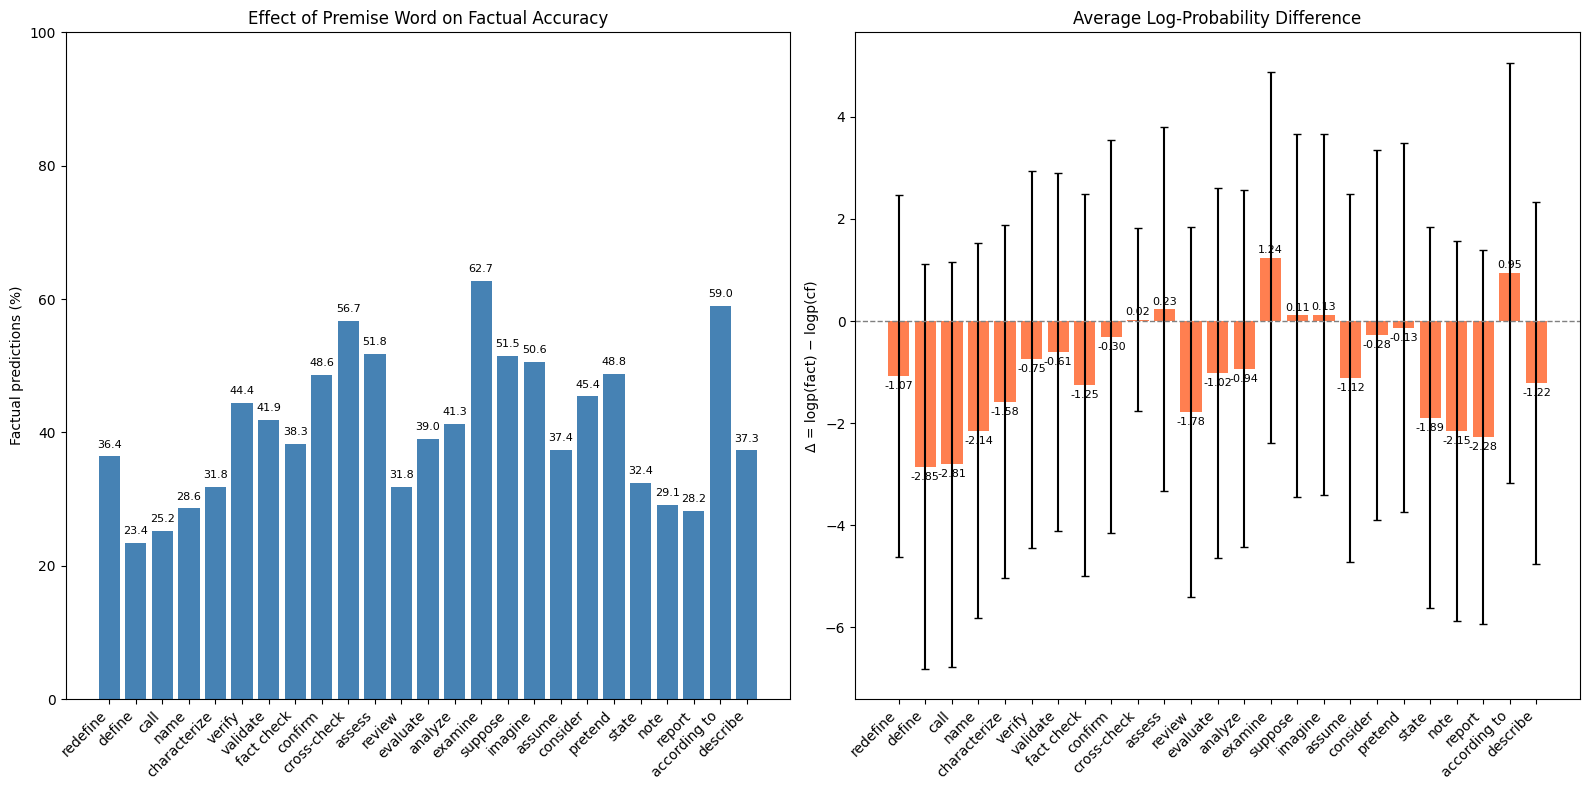

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Medium
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Premise Words:** 'redefine', 'define', 'call', 'name', 'characterize'

Loading model 'gpt2-medium' on cuda...


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:15<00:00, 13.16it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   54.9000 45.1000     -1.9753   -1.8663 -0.1090 1.7916
      define   1000   28.3000 71.7000    -12.1057   -9.5542 -2.5515 3.9873
        call   1000   31.0000 69.0000    -12.5790  -10.4616 -2.1173 3.9302
        name   1000   37.0000 63.0000    -11.9321  -10.5583 -1.3739 3.6610
characterize   1000   33.9000 66.1000    -12.1000  -10.6301 -1.4699 3.5003

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 37.02%, Avg CounterFact: 62.98%, Average Log-Fact: -10.1384, Average Log-CFact: -8.6141, Avg Δ: -1.5243

 Results saved to 'premise_word_results.csv'


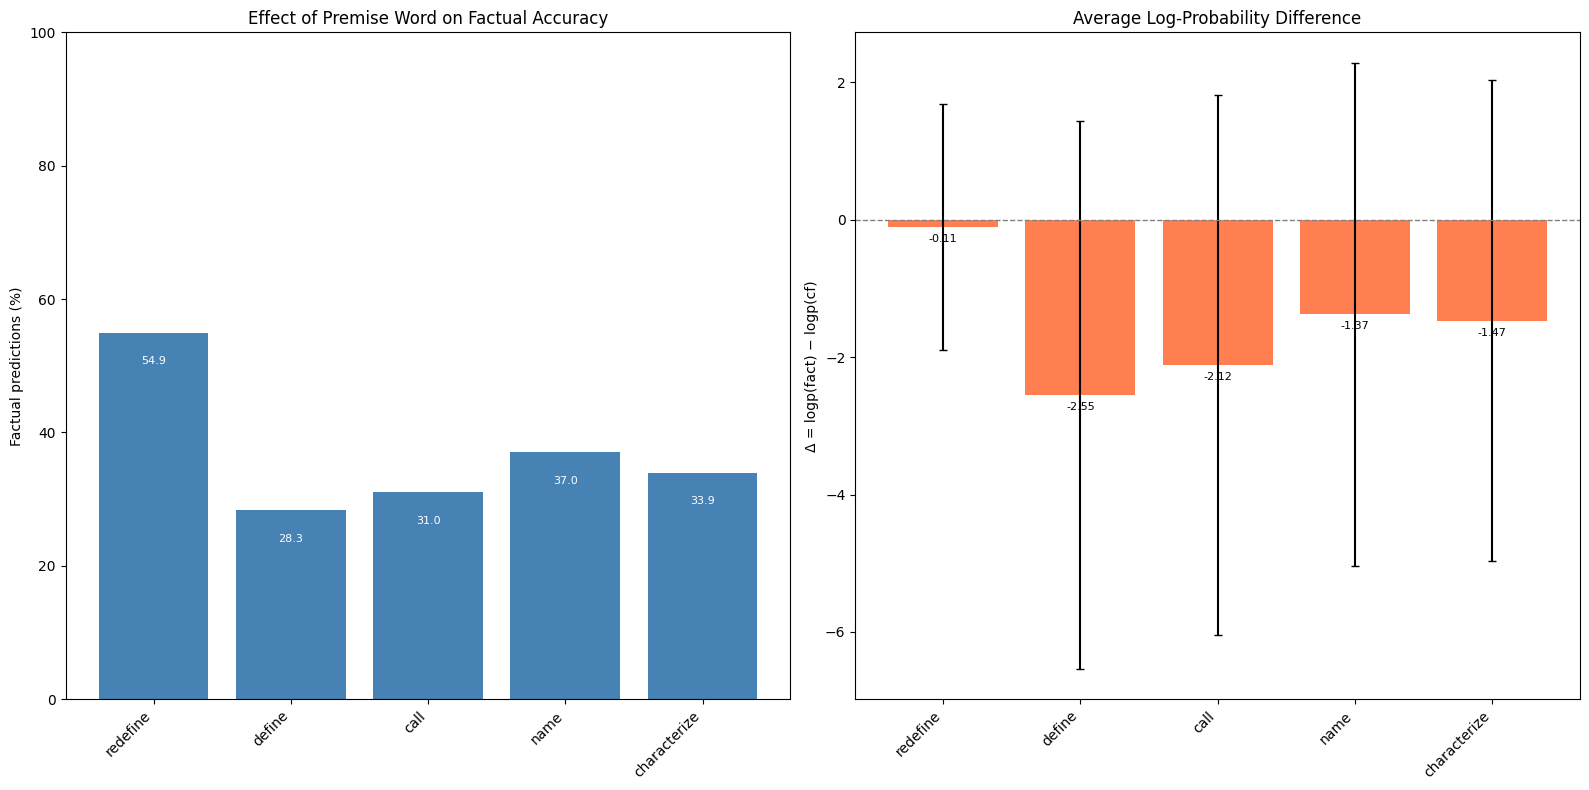

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        # 'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        # 'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        # 'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        # 'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Mediummm
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Premise Words:** 'verify', 'validate', 'fact check', 'confirm', 'cross-check'

Loading model 'gpt2-medium' on cuda...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:12<00:00, 13.87it/s]



EFFECT OF PREMISE WORDS
    Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
     verify   1000   44.7000 55.3000    -11.0183  -10.2971 -0.7212 3.6972
   validate   1000   41.5000 58.5000     -9.5626   -8.9474 -0.6151 3.5054
 fact check   1000   38.4000 61.6000    -11.5166  -10.2491 -1.2675 3.7453
    confirm   1000   48.4000 51.6000     -9.7898   -9.4823 -0.3075 3.8535
cross-check   1000   57.1000 42.9000     -1.8236   -1.8480  0.0244 1.7950

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 46.02%, Avg CounterFact: 53.98%, Average Log-Fact: -8.7422, Average Log-CFact: -8.1648, Avg Δ: -0.5774

 Results saved to 'premise_word_results.csv'


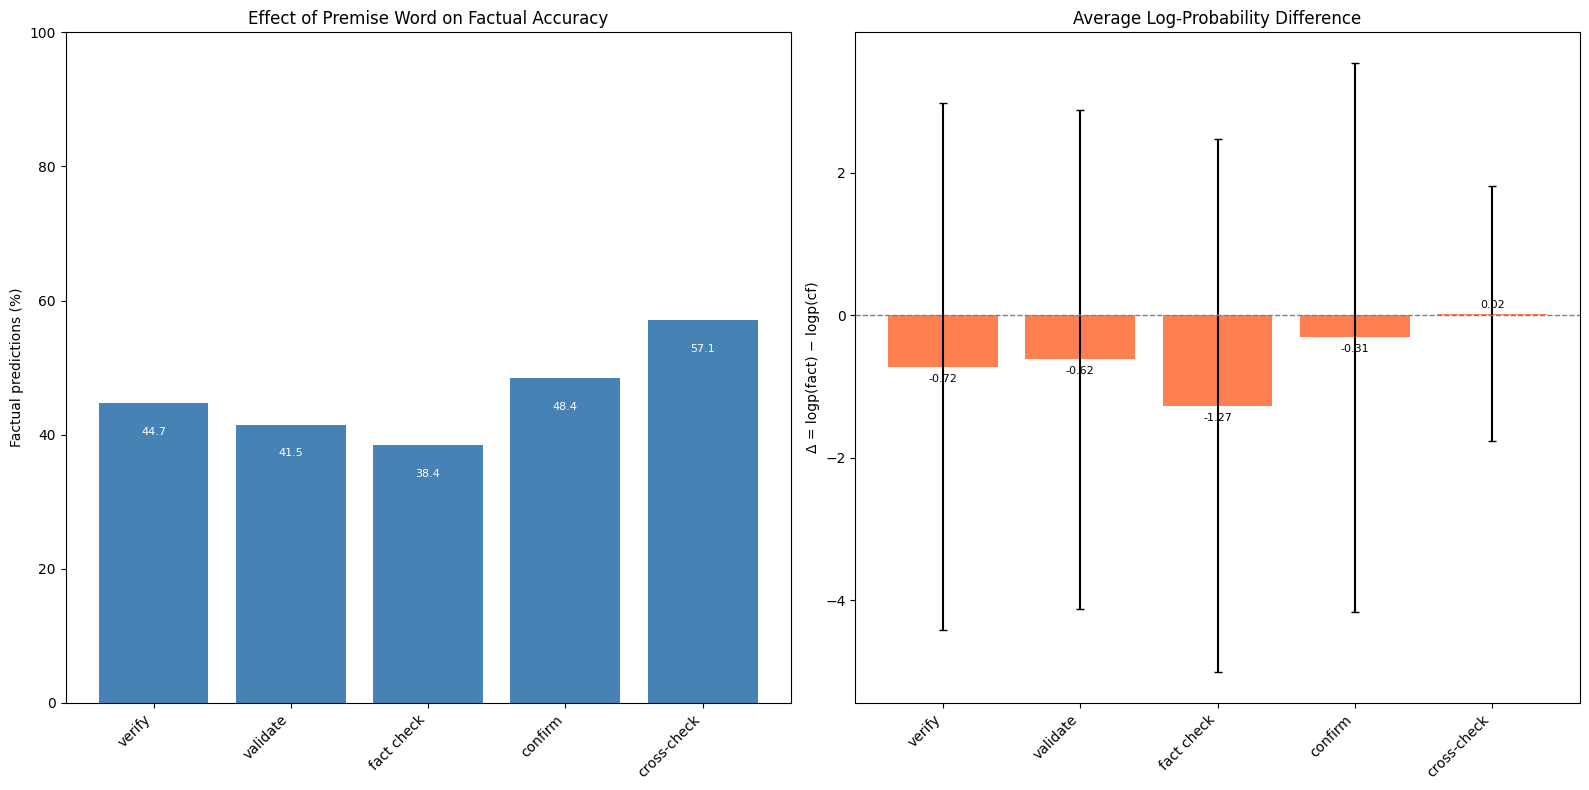

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        # 'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        # 'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        # 'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        # 'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Mediumm
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Premise Words:** 'assess', 'review', 'evaluate', 'analyze', 'examine'

Loading model 'gpt2-medium' on cuda...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:48<00:00, 20.51it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
  assess   1000   55.1000 44.9000     -1.8679   -1.8571 -0.0108 1.8247
  review   1000   58.9000 41.1000     -1.8284   -1.9472  0.1188 1.7756
evaluate   1000   52.7000 47.3000     -1.9651   -1.8031 -0.1620 1.7914
 analyze   1000   52.9000 47.1000     -1.9812   -1.8424 -0.1389 1.7952
 examine   1000   53.9000 46.1000     -2.0150   -1.8675 -0.1475 1.7932

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 54.70%, Avg CounterFact: 45.30%, Average Log-Fact: -1.9315, Average Log-CFact: -1.8634, Avg Δ: -0.0681

 Results saved to 'premise_word_results.csv'


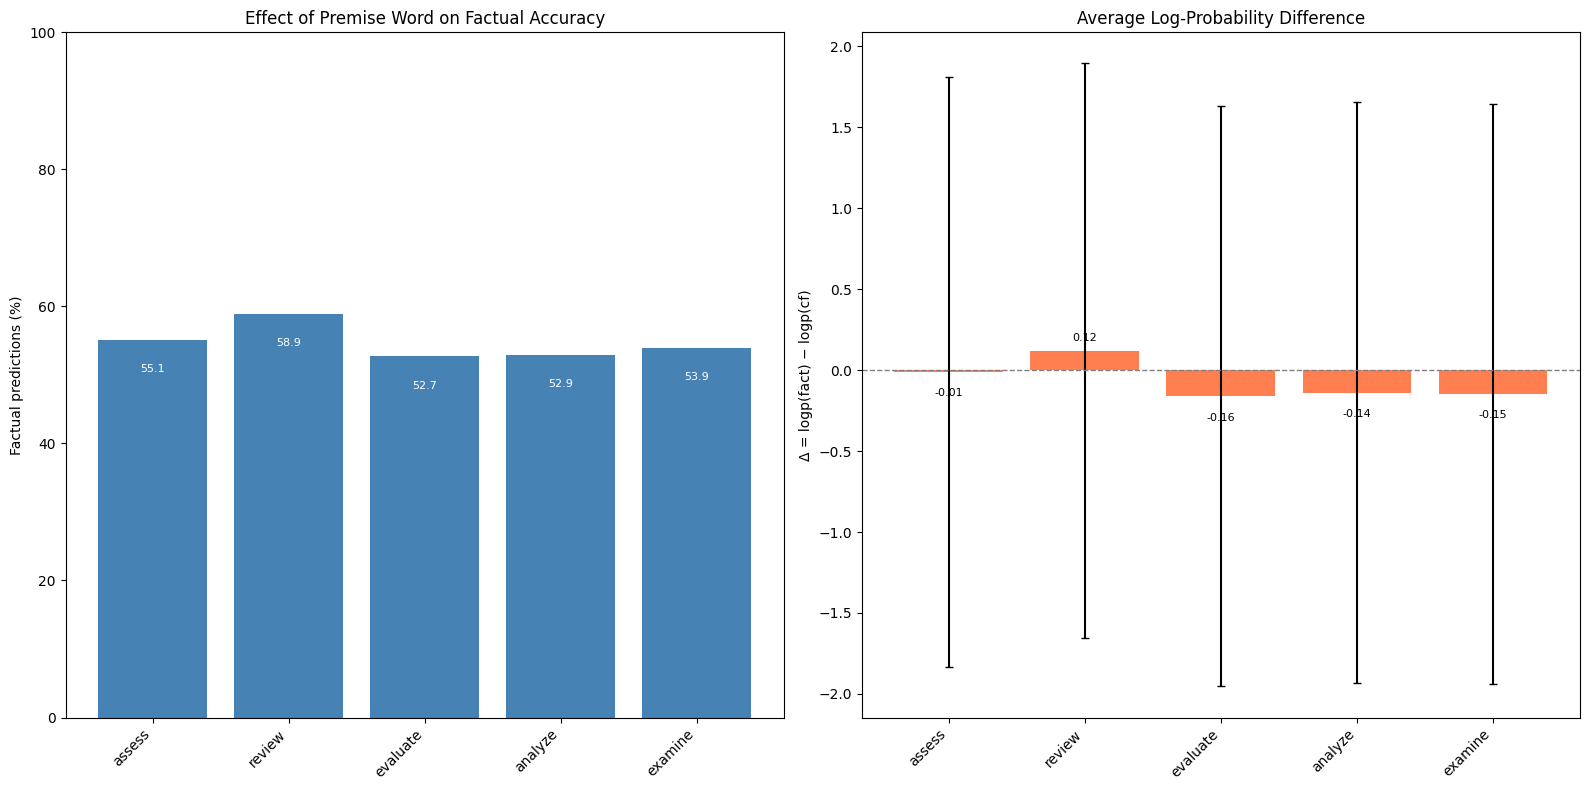

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        # 'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        # 'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        # 'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        # 'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Mediumm
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Premise Words:** 'suppose', 'imagine', 'assume', 'consider', 'pretend'

Loading model 'gpt2-medium' on cuda...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:49<00:00, 20.21it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
 suppose   1000   45.5000 54.5000     -2.2123   -1.8204 -0.3919 1.6894
 imagine   1000   53.7000 46.3000     -2.0396   -1.9107 -0.1290 1.7607
  assume   1000   49.0000 51.0000     -2.0050   -1.7528 -0.2522 1.7295
consider   1000   53.9000 46.1000     -1.9502   -1.8211 -0.1291 1.7641
 pretend   1000   51.1000 48.9000     -1.9737   -1.7745 -0.1992 1.7032

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 50.64%, Avg CounterFact: 49.36%, Average Log-Fact: -2.0361, Average Log-CFact: -1.8159, Avg Δ: -0.2203

 Results saved to 'premise_word_results.csv'


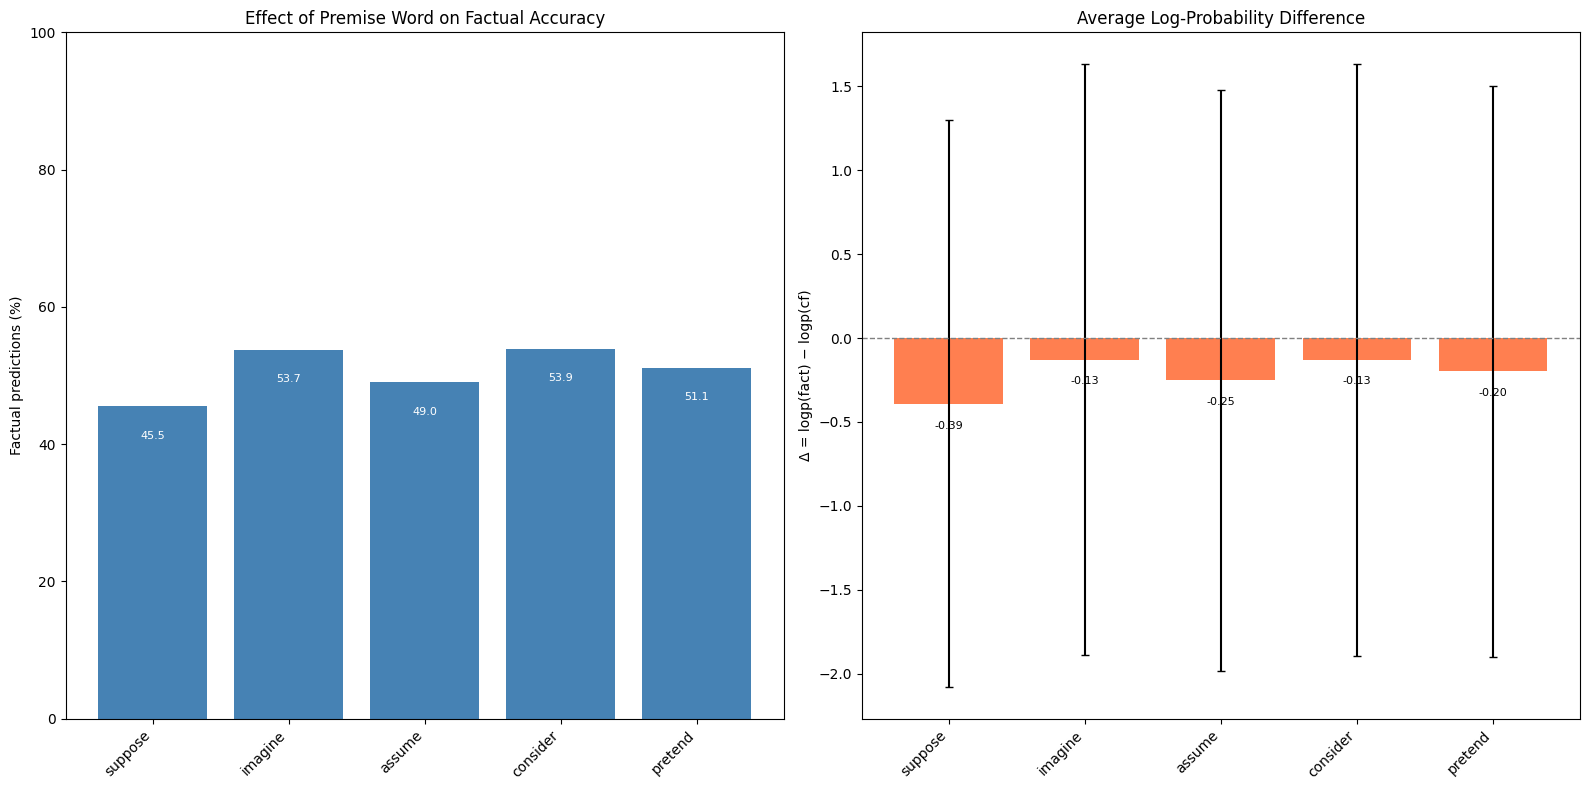

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        # 'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        # 'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        # 'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        # 'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Mediumm
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()

# **Premise Words:** 'state', 'note', 'report', 'according to', 'describe'

Loading model 'gpt2-medium' on cuda...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [00:53<00:00, 18.70it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
       state   1000   33.3000 66.7000    -12.0631  -10.3035 -1.7596 3.7649
        note   1000   31.8000 68.2000    -12.3239  -10.4790 -1.8449 3.7427
      report   1000   34.1000 65.9000    -12.5039  -10.8618 -1.6421 3.6410
according to   1000   57.3000 42.7000     -1.9650   -1.9843  0.0193 1.8212
    describe   1000   44.5000 55.5000    -11.4817  -10.9194 -0.5623 3.5509

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 40.20%, Avg CounterFact: 59.80%, Average Log-Fact: -10.0676, Average Log-CFact: -8.9096, Avg Δ: -1.1579

 Results saved to 'premise_word_results.csv'


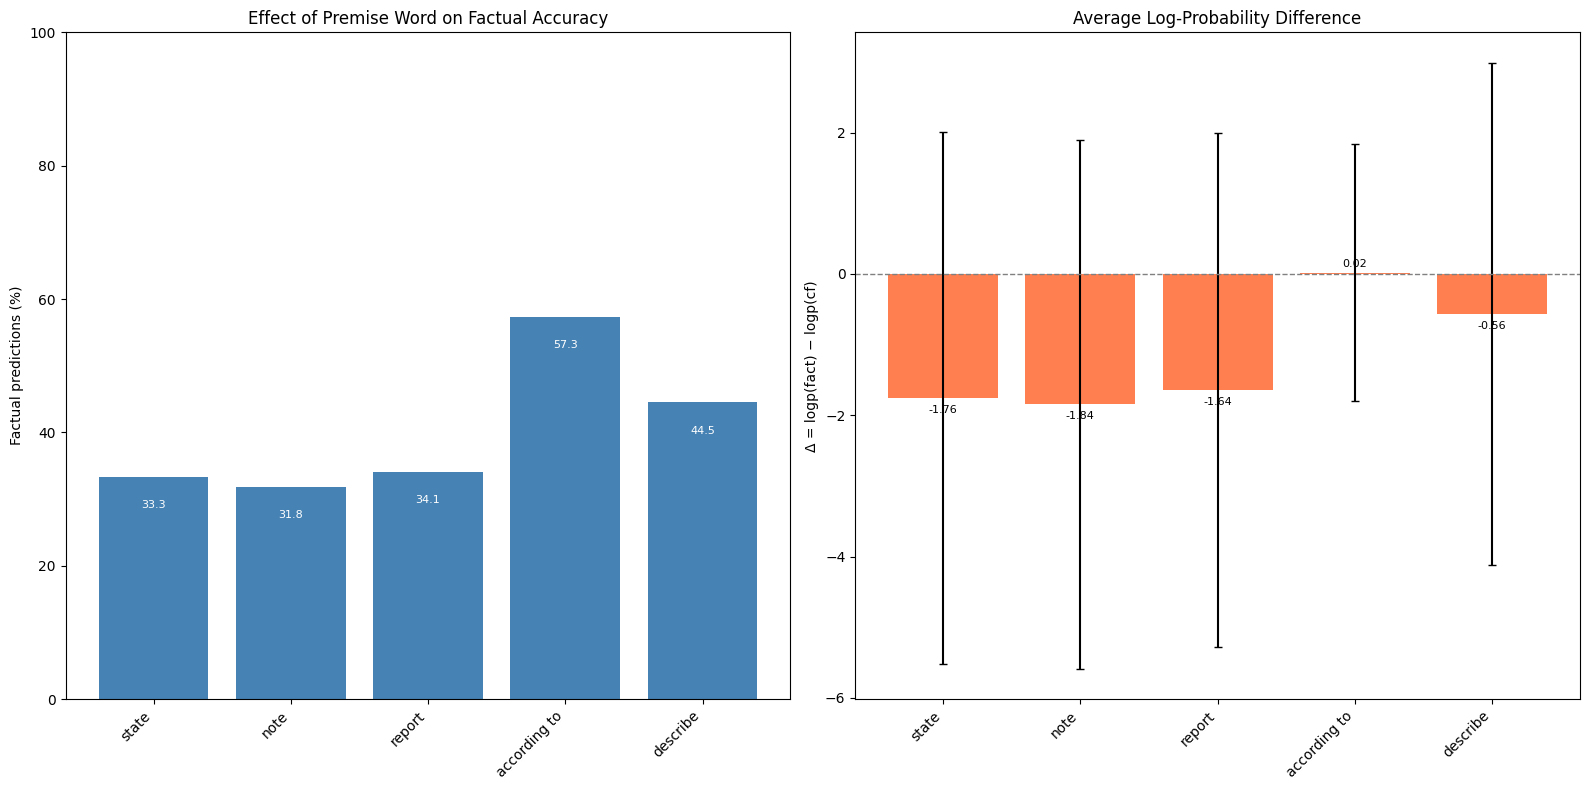

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        # 'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        # 'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        # 'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        # 'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 5,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with GPT-2 Mediumm
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='gpt2-medium',
        max_samples=1000
    )
    analyzer.run()